# Mini-Projet — Planification Robuste sur Grille
## A* + Chaînes de Markov

**Module :** Base de l'Intelligence Artificielle  
---

### Objectifs
Ce notebook implémente et illustre les deux notions du projet :
1. **Recherche heuristique** (UCS / Greedy / A*) — planification déterministe sur grille 2D
2. **Chaînes de Markov** — modélisation de l'incertitude d'action et évaluation de la robustesse

### Structure
- **Section 0** : Imports et définition des grilles 
- **Section 1** : Module `astar.py` — heuristiques, `neighbors()`, `astar()`, variantes, politique
- **Section 2** : Module `markov.py` — construction de P, π^(n), classes, absorption, simulation
- **Section 3** : Expérience E.1 — Comparaison UCS / Greedy / A*
- **Section 4** : Expérience E.2 — Impact de ε sur le plan A*
- **Section 5** : Expérience E.3 — Heuristiques h=0 vs Manhattan
- **Section 6** : Expérience E.4 — Weighted A*
- **Section 7** : Analyse Markov complète 
- **Section 8** : Graphe de transitions de la chaîne de markov

---
## Section 0 — Imports & Grilles 

In [1]:
import heapq, time, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import defaultdict
import warnings; warnings.filterwarnings('ignore')

# Palette graphique
C = {
    'bg':'#F8F9FA', 'wall':'#2C3E50', 'free':'#FFFFFF',
    'start':'#E67E22', 'goal':'#8E44AD',
    'ucs':'#2980B9', 'greedy':'#E74C3C', 'astar':'#27AE60',
    'markov':'#1ABC9C', 'sim':'#E67E22', 'visited':'#D5E8F5'
}
print('Imports OK')

Imports OK


In [2]:
# Définition des 3 grilles (0=libre, 1=obstacle) ────────────────────

GRID_EASY = np.array([
    [0,0,0,0,0,0,0,0],
    [0,1,1,0,0,0,0,0],
    [0,0,0,0,1,0,0,0],
    [0,0,1,0,1,0,0,0],
    [0,0,1,0,0,0,1,0],
    [0,0,0,0,0,0,1,0],
    [0,0,0,1,0,0,0,0],
    [0,0,0,0,0,0,0,0],
], dtype=int)
START_EASY, GOAL_EASY = (0,0), (7,7)

GRID_MEDIUM = np.array([
    [0,0,0,0,0,1,0,0,0,0,0,0],
    [0,1,1,1,0,1,0,1,1,1,0,0],
    [0,0,0,1,0,0,0,0,0,1,0,0],
    [0,0,0,1,1,1,1,0,0,1,0,0],
    [0,0,0,0,0,0,1,0,0,0,0,0],
    [0,1,0,0,0,0,1,0,1,1,1,0],
    [0,1,0,1,1,0,0,0,0,0,1,0],
    [0,1,0,0,1,0,0,1,0,0,1,0],
    [0,0,0,0,1,0,0,1,0,0,0,0],
    [1,1,1,0,0,0,0,1,0,1,1,0],
    [0,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0],
], dtype=int)
START_MEDIUM, GOAL_MEDIUM = (0,0), (11,11)

def _build_hard_grid():
    g = np.zeros((16,16), dtype=int)
    for r,c in [
        (0,3),(1,3),(2,3),(4,3),(5,3),(6,3),
        (0,7),(1,7),(2,7),(3,7),(4,7),(5,7),(6,7),
        (0,11),(1,11),(2,11),(3,11),(4,11),(5,11),(6,11),
        (9,0),(9,1),(9,2),(9,4),(9,5),(9,6),(9,7),(9,8),
        (12,8),(12,9),(12,10),(12,11),(12,12),(12,13),(12,14),(12,15),
        (2,5),(2,6),(5,9),(5,10),(8,12),(8,13),
        (10,4),(10,5),(11,1),(11,2),(13,3),(14,6),(15,10)
    ]:
        g[r,c] = 1
    return g

GRID_HARD = _build_hard_grid()
START_HARD, GOAL_HARD = (0,0), (15,15)

GRIDS = {
    'Facile (8×8)'      : (GRID_EASY,   START_EASY,   GOAL_EASY),
    'Moyenne (12×12)'   : (GRID_MEDIUM, START_MEDIUM, GOAL_MEDIUM),
    'Difficile (16×16)' : (GRID_HARD,   START_HARD,   GOAL_HARD),
}

# ── P1.2 — Coût uniforme c(n,n') = 1  (déclaré implicitement dans astar)
# ── P1.3 — Niveaux d'incertitude
EPSILONS = [0.0, 0.1, 0.2, 0.3]
print('Grilles définies :', list(GRIDS.keys()))

Grilles définies : ['Facile (8×8)', 'Moyenne (12×12)', 'Difficile (16×16)']


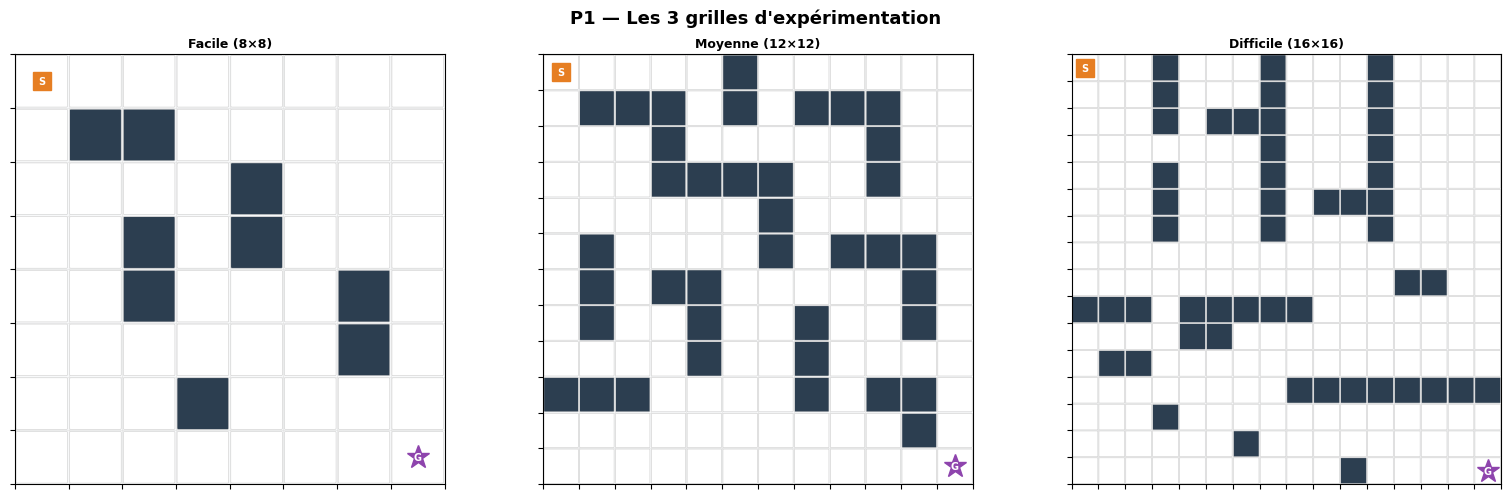

In [3]:
def draw_grid(ax, grid, path=None, start=None, goal=None,
              path_color='#27AE60', title=''):
    """Utilitaire de visualisation de la grille."""
    rows, cols = grid.shape
    ax.set_xlim(0, cols); ax.set_ylim(0, rows)
    ax.set_aspect('equal'); ax.set_facecolor(C['bg'])
    for r in range(rows):
        for c in range(cols):
            color = C['wall'] if grid[r,c]==1 else C['free']
            rect = mpatches.FancyBboxPatch(
                (c+.04, rows-r-1+.04), .92, .92,
                boxstyle='round,pad=0.02', lw=.4,
                edgecolor='#CCC', facecolor=color)
            ax.add_patch(rect)
    if path and len(path)>1:
        xs=[c+.5 for r,c in path]; ys=[rows-r-.5 for r,c in path]
        ax.plot(xs, ys, '-', color=path_color, lw=2.2, zorder=3)
    if start:
        r,c=start; ax.plot(c+.5,rows-r-.5,'s',ms=13,color=C['start'],zorder=5)
        ax.text(c+.5,rows-r-.5,'S',ha='center',va='center',
                fontsize=7,fontweight='bold',color='white',zorder=6)
    if goal:
        r,c=goal; ax.plot(c+.5,rows-r-.5,'*',ms=17,color=C['goal'],zorder=5)
        ax.text(c+.5,rows-r-.5,'G',ha='center',va='center',
                fontsize=7,fontweight='bold',color='white',zorder=6)
    ax.set_xticks(range(cols+1)); ax.set_yticks(range(rows+1))
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.grid(True, color='#E0E0E0', lw=.4)
    if title: ax.set_title(title, fontsize=9, fontweight='bold', pad=5)

# Aperçu des 3 grilles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('P1 — Les 3 grilles d\'expérimentation', fontsize=13, fontweight='bold')
for ax, (gname, (grid, start, goal)) in zip(axes, GRIDS.items()):
    draw_grid(ax, grid, start=start, goal=goal, title=gname)
plt.tight_layout(); plt.show()

---
## Section 1 — Module `astar.py` 

Implémentation du squelette fourni par le professeur :
```python
# 1) A* sur grille : neighbors(), astar()
# 2) Politique induite par le chemin : pi[state] -> action
```
### Heuristique admissible et cohérente
$$h((x,y)) = |x - x_g| + |y - y_g| \quad \text{(Manhattan)}$$
- **Admissible** : $h(n) \leq h^*(n)$ — ne surestime jamais le coût réel
- **Cohérente** : $h(n) \leq c(n,n') + h(n')$ — implique admissibilité + pas de ré-expansion

In [4]:
# ── Heuristiques ───

def manhattan(p, goal):
    """Heuristique de Manhattan — admissible et cohérente."""
    return abs(p[0]-goal[0]) + abs(p[1]-goal[1])

def zero_heuristic(p, goal):
    """h=0 — admissible triviale, dégénère A* en UCS."""
    return 0

# Vérification admissibilité sur un exemple
p, g = (0,0), (5,5)
print(f'h_manhattan({p}, {g}) = {manhattan(p,g)}  (distance réelle min = 10)')
print(f'h_zero    ({p}, {g}) = {zero_heuristic(p,g)}')
print('→ Manhattan est admissible (ne dépasse pas 10)')

h_manhattan((0, 0), (5, 5)) = 10  (distance réelle min = 10)
h_zero    ((0, 0), (5, 5)) = 0
→ Manhattan est admissible (ne dépasse pas 10)


In [5]:
# ── neighbors(state, grid) ──────────

def neighbors(state, grid):
    """
    Retourne les voisins valides (4-connexité) d'un état dans la grille.
    0 = libre, 1 = obstacle.
    """
    rows, cols = len(grid), len(grid[0])
    r, c = state
    result = []
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:  # haut, bas, gauche, droite
        nr, nc = r+dr, c+dc
        if 0<=nr<rows and 0<=nc<cols and grid[nr][nc]==0:
            result.append((nr, nc))
    return result

# Test
test_state = (1, 1)
print(f'Voisins de {test_state} dans GRID_EASY :')
print(neighbors(test_state, GRID_EASY))

Voisins de (1, 1) dans GRID_EASY :
[(0, 1), (2, 1), (1, 0)]


In [6]:
# ── astar() — algorithme générique OPEN/CLOSED ───────────────────────────────

def _reconstruct_path(came_from, goal):
    path, node = [], goal
    while node is not None:
        path.append(node); node = came_from[node]
    path.reverse()
    return path

def astar(grid, start, goal, h=manhattan, weight=1.0):
    """
    A* générique sur grille 2D — coût uniforme c(n,n')=1.

    f(n) = g(n) + weight * h(n)
      weight=1.0   → A* standard (optimal si h admissible)
      weight=0.0   → UCS / Dijkstra
      weight>1.0   → Weighted A* (ε-sous-optimal)

    OPEN  : tas min sur f(n)      (heapq)
    CLOSED: ensemble des développés (set)
    """
    t0 = time.perf_counter()
    open_heap = []
    heapq.heappush(open_heap, (h(start,goal), 0.0, start))
    g_score  = {start: 0.0}
    came_from= {start: None}
    closed   = set()
    expanded = 0; open_max = 1

    while open_heap:
        open_max = max(open_max, len(open_heap))
        f_cur, g_cur, current = heapq.heappop(open_heap)
        if current in closed: continue
        closed.add(current); expanded += 1

        if current == goal:
            path = _reconstruct_path(came_from, goal)
            elapsed = time.perf_counter()-t0
            return path, g_cur, expanded, open_max, elapsed

        for nb in neighbors(current, grid):
            new_g = g_cur + 1                          # coût uniforme
            if nb in closed: continue
            if new_g < g_score.get(nb, float('inf')):
                g_score[nb]   = new_g
                came_from[nb] = current
                f_val = new_g + weight * h(nb, goal)
                heapq.heappush(open_heap, (f_val, new_g, nb))

    elapsed = time.perf_counter()-t0
    return [], float('inf'), expanded, open_max, elapsed

# Test rapide
path, cost, exp, om, el = astar(GRID_EASY, START_EASY, GOAL_EASY)
print(f'A* sur Grille Facile : coût={cost:.0f}, nœuds={exp}, chemin={path[:4]}...')

A* sur Grille Facile : coût=14, nœuds=55, chemin=[(0, 0), (0, 1), (0, 2), (0, 3)]...


In [7]:
# ── Variantes  ─────────────────────────────────────────────────────────

def ucs(grid, start, goal):
    """UCS : f(n) = g(n)  [h=0]"""
    return astar(grid, start, goal, h=zero_heuristic, weight=1.0)

def greedy(grid, start, goal):
    """Greedy Best-First : f(n) = h(n)  [g ignoré]"""
    t0 = time.perf_counter()
    open_heap = [(manhattan(start,goal), start)]
    came_from = {start: None}
    visited   = set()
    expanded  = 0; open_max = 1
    while open_heap:
        open_max = max(open_max, len(open_heap))
        h_cur, current = heapq.heappop(open_heap)
        if current in visited: continue
        visited.add(current); expanded += 1
        if current == goal:
            path = _reconstruct_path(came_from, goal)
            g_real = len(path)-1
            return path, g_real, expanded, open_max, time.perf_counter()-t0
        for nb in neighbors(current, grid):
            if nb not in visited and nb not in came_from:
                came_from[nb] = current
                heapq.heappush(open_heap, (manhattan(nb,goal), nb))
    return [], float('inf'), expanded, open_max, time.perf_counter()-t0

def astar_manhattan(grid, start, goal):
    """A* standard avec h=Manhattan."""
    return astar(grid, start, goal, h=manhattan, weight=1.0)

def weighted_astar(grid, start, goal, w=2.0):
    """Weighted A* : f(n) = g(n) + w·h(n), w>1."""
    return astar(grid, start, goal, h=manhattan, weight=w)

# Comparaison rapide
for name, fn in [('UCS', ucs), ('Greedy', greedy), ('A*', astar_manhattan)]:
    p, c, e, om, el = fn(GRID_MEDIUM, START_MEDIUM, GOAL_MEDIUM)
    print(f'  {name:8s} | Coût={c:.0f}  Nœuds={e:4d}  OPEN_max={om:3d}  {el*1000:.2f}ms')

  UCS      | Coût=22  Nœuds= 106  OPEN_max= 12  0.70ms
  Greedy   | Coût=22  Nœuds=  23  OPEN_max=  8  0.09ms
  A*       | Coût=22  Nœuds=  87  OPEN_max= 11  0.58ms


In [8]:
# ── extract_policy ──────────

DELTA_TO_ACTION = {(-1,0):'UP',(1,0):'DOWN',(0,-1):'LEFT',(0,1):'RIGHT'}

def extract_policy(path):
    """
    Construit π : état → (action, état_suivant) depuis le chemin planifié.
    Dernier état → ('STAY', dernier_état)  [état but absorbant]
    """
    policy = {}
    for i in range(len(path)-1):
        s, s_next = path[i], path[i+1]
        dr, dc = s_next[0]-s[0], s_next[1]-s[1]
        policy[s] = (DELTA_TO_ACTION[(dr,dc)], s_next)
    policy[path[-1]] = ('STAY', path[-1])   # but
    return policy

path, *_ = astar_manhattan(GRID_EASY, START_EASY, GOAL_EASY)
policy   = extract_policy(path)
print('Politique sur les 5 premiers états du chemin :')
for s in path[:5]:
    print(f'  π[{s}] = {policy[s]}')

Politique sur les 5 premiers états du chemin :
  π[(0, 0)] = ('RIGHT', (0, 1))
  π[(0, 1)] = ('RIGHT', (0, 2))
  π[(0, 2)] = ('RIGHT', (0, 3))
  π[(0, 3)] = ('RIGHT', (0, 4))
  π[(0, 4)] = ('RIGHT', (0, 5))


---
## Section 2 — Module `markov.py` 

```python
# 3) Construction de P (Markov) à partir de la politique + epsilon
# 4) Calcul π^(n) = π0 @ P^n
# 5) Simulation Markov : trajectoires, stats (proba GOAL, temps)
```
### Modèle stochastique
$$P(X_{n+1}=j \mid X_n=i) = p_{ij}, \qquad P=(p_{ij}) \text{ stochastique par lignes}$$

Avec incertitude $\varepsilon$ :
- action voulue → $1-\varepsilon$
- déviation latérale ×2 → $\varepsilon/2$ chacune
- collision → état **FAIL** (absorbant)

In [9]:
# ── États absorbants  ────────────────
GOAL_STATE = 'GOAL'   # p(GOAL,GOAL) = 1
FAIL_STATE = 'FAIL'   # p(FAIL,FAIL) = 1

ACTION_DELTA = {'UP':(-1,0),'DOWN':(1,0),'LEFT':(0,-1),'RIGHT':(0,1),'STAY':(0,0)}
LATERAL      = {'UP':['LEFT','RIGHT'],'DOWN':['LEFT','RIGHT'],
                 'LEFT':['UP','DOWN'],'RIGHT':['UP','DOWN'],'STAY':[]}

In [10]:
# ── Construction de P ─────────────────────────────────────────────────

def build_transition_matrix(grid, policy, epsilon=0.1):
    """
    Construit la matrice de transition P (stochastique) à partir de la
    politique et du taux d'incertitude ε.
    """
    rows, cols = len(grid), len(grid[0])
    path_states = [s for s in policy if s not in (GOAL_STATE, FAIL_STATE)]
    all_states  = path_states + [GOAL_STATE, FAIL_STATE]
    state_idx   = {s:i for i,s in enumerate(all_states)}
    n           = len(all_states)
    P = np.zeros((n, n))

    def target(s, act):
        """Cellule résultante si on applique act depuis s (None si collision)."""
        dr, dc = ACTION_DELTA[act]
        nr, nc = s[0]+dr, s[1]+dc
        if 0<=nr<rows and 0<=nc<cols and grid[nr][nc]==0:
            return (nr, nc)
        return None

    def add_prob(i, cell, prob):
        if cell is None:
            P[i, state_idx[FAIL_STATE]] += prob
        elif cell in state_idx:
            P[i, state_idx[cell]]       += prob
        else:
            P[i, state_idx[FAIL_STATE]] += prob

    for s, (action, _) in policy.items():
        i = state_idx[s]
        if action == 'STAY':
            P[i, state_idx[GOAL_STATE]] = 1.0
            continue
        main_cell = target(s, action)
        lat_cells = [target(s, d) for d in LATERAL[action]]
        add_prob(i, main_cell, 1.0 - epsilon)
        if len(lat_cells) == 2:
            add_prob(i, lat_cells[0], epsilon/2)
            add_prob(i, lat_cells[1], epsilon/2)

    # États absorbants
    for absorb in [GOAL_STATE, FAIL_STATE]:
        idx = state_idx[absorb]
        P[idx,:] = 0.0; P[idx, idx] = 1.0

    # P3.2 — Vérification stochasticité
    row_sums = P.sum(axis=1)
    for i in range(n):
        s = row_sums[i]
        if abs(s-1.0)>1e-9:
            P[i] = P[i]/s if s>0 else (P[i, i:=i]*0, P[i,i]).__setitem__(0, 1.0) or P[i]

    return P, all_states, state_idx

path, *_ = astar_manhattan(GRID_EASY, START_EASY, GOAL_EASY)
policy   = extract_policy(path)
P, states, sidx = build_transition_matrix(GRID_EASY, policy, epsilon=0.1)
print(f'Matrice P : {P.shape[0]} états')
print(f'Vérification stochasticité (somme lignes) : max écart = {abs(P.sum(axis=1)-1).max():.2e}')

Matrice P : 17 états
Vérification stochasticité (somme lignes) : max écart = 0.00e+00


In [11]:
# ── — Calcul π^(n) = π^(0) · P^n ────────────────

def compute_pi_n(pi0, P, n_steps):
    """
    Calcule π^(n) = π^(0) · P^n pour n=0,...,n_steps
    par multiplications successives (Chapman-Kolmogorov).
    Retourne history[t] = π^(t).
    """
    history    = np.zeros((n_steps+1, len(pi0)))
    history[0] = pi0.copy()
    pi = pi0.copy()
    for t in range(1, n_steps+1):
        pi = pi @ P           # π^(t) = π^(t-1) · P
        history[t] = pi
    return history

# Vérification avec P^n directement
def compute_Pn(P, n):
    """P^n par exponentiation rapide."""
    result = np.eye(len(P)); base = P.copy()
    while n > 0:
        if n%2==1: result = result @ base
        base = base @ base; n //= 2
    return result

pi0 = np.zeros(len(states))
pi0[sidx[START_EASY]] = 1.0
history = compute_pi_n(pi0, P, 50)

# Vérification Chapman-Kolmogorov : π^(10) = π^(0)·P^10
pi10_direct = pi0 @ compute_Pn(P, 10)
pi10_iter   = history[10]
print(f'Chapman-Kolmogorov — écart entre itératif et P^10 : {np.abs(pi10_direct-pi10_iter).max():.2e}')
print(f'P(GOAL à n=50) = {history[50, sidx[GOAL_STATE]]:.4f}')

Chapman-Kolmogorov — écart entre itératif et P^10 : 1.11e-16
P(GOAL à n=50) = 0.2395


In [12]:
# ── Classes de communication (Kosaraju) ───────────────────────────────

def find_communication_classes(P, states):
    """
    Identifie les SCC (classes de communication) par algorithme de Kosaraju.
    Retourne : classes (list of set), class_type (dict → Récurrent|Transitoire)
    """
    n = len(states)
    visited = [False]*n; finish_order = []

    def dfs1(v):
        stack = [(v, iter(range(n)))]; visited[v] = True
        while stack:
            node, ch = stack[-1]
            try:
                w = next(ch)
                if P[node,w]>1e-9 and not visited[w]:
                    visited[w]=True; stack.append((w, iter(range(n))))
            except StopIteration:
                finish_order.append(node); stack.pop()

    for v in range(n):
        if not visited[v]: dfs1(v)

    visited2 = [False]*n; components = []
    def dfs2(v, comp):
        stack = [v]; visited2[v] = True
        while stack:
            node = stack.pop(); comp.append(node)
            for w in range(n):
                if P[w,node]>1e-9 and not visited2[w]:
                    visited2[w]=True; stack.append(w)

    for v in reversed(finish_order):
        if not visited2[v]:
            comp=[]; dfs2(v, comp); components.append(comp)

    classes=[]; class_type={}
    for comp in components:
        scc = {states[i] for i in comp}
        is_closed = all(P[i,j]<1e-9 for i in comp for j in range(n) if j not in comp)
        t = 'Récurrent' if is_closed else 'Transitoire'
        classes.append(scc)
        for i in comp: class_type[states[i]] = t
    return classes, class_type

classes, ctype = find_communication_classes(P, states)
n_rec = sum(1 for t in ctype.values() if t=='Récurrent')
n_tr  = sum(1 for t in ctype.values() if t=='Transitoire')
print(f'Nombre de classes : {len(classes)}')
print(f'  États récurrents  : {n_rec}  (dont GOAL et FAIL)')
print(f'  États transitoires : {n_tr}')

Nombre de classes : 16
  États récurrents  : 2  (dont GOAL et FAIL)
  États transitoires : 15


In [13]:
# ── Analyse d'absorption : N = (I-Q)^{-1}, B = N·R ───────────────────

def absorption_analysis(P, states, state_idx):
    """
    Décomposition P = [I 0 / R Q].
    Matrice fondamentale N = (I-Q)^{-1}.
    Probabilités d'absorption B = N·R.
    Temps moyen t̄_i = Σ_j N_{ij}.
    """
    absorbing_set = {GOAL_STATE, FAIL_STATE}
    trans = [s for s in states if s not in absorbing_set]
    absorb= [s for s in states if s     in absorbing_set]
    if not trans or not absorb: return None

    t_idx = [state_idx[s] for s in trans]
    a_idx = [state_idx[s] for s in absorb]
    Q = P[np.ix_(t_idx, t_idx)]
    R = P[np.ix_(t_idx, a_idx)]

    try:
        N      = np.linalg.inv(np.eye(len(trans)) - Q)
        B      = N @ R
        t_mean = N.sum(axis=1)
    except np.linalg.LinAlgError:
        return None

    return {'N':N, 'B':B, 't_mean':t_mean,
            'transient_states':trans, 'absorbing_states':absorb}

absorp = absorption_analysis(P, states, sidx)
if absorp:
    tr  = absorp['transient_states']
    ab  = absorp['absorbing_states']
    s_i = tr.index(START_EASY)
    g_j = ab.index(GOAL_STATE)
    print(f'Absorption depuis START={START_EASY} :')
    print(f'  Pb(GOAL) matriciel = {absorp["B"][s_i,g_j]:.4f}')
    print(f'  Pb(FAIL) matriciel = {absorp["B"][s_i,1-g_j]:.4f}')
    print(f'  Temps moyen (fond) = {absorp["t_mean"][s_i]:.2f} étapes') 

Absorption depuis START=(0, 0) :
  Pb(GOAL) matriciel = 0.2395
  Pb(FAIL) matriciel = 0.7605
  Temps moyen (fond) = 8.09 étapes


In [14]:
# ── Simulation Monte-Carlo ───────────────────────────────────────────────

def simulate(policy, grid, start, epsilon=0.1, N=5000, max_steps=300, seed=42):
    """
    Simule N trajectoires Markov selon la politique avec incertitude ε.
    Retourne : prob_goal, prob_fail, prob_stuck, mean_time, std_time, times.
    """
    rng  = np.random.default_rng(seed)
    rows, cols = len(grid), len(grid[0])
    n_goal=0; n_fail=0; n_stuck=0; times=[]

    for _ in range(N):
        state = start
        for step in range(max_steps):
            if state not in policy: n_stuck+=1; break
            action, _ = policy[state]
            if action == 'STAY': n_goal+=1; times.append(step); break

            lats = LATERAL[action]; r = rng.random()
            if r < 1.0-epsilon:          chosen = action
            elif len(lats)==2:
                chosen = lats[0] if r<1.0-epsilon/2 else lats[1]
            else: chosen = action

            dr, dc = ACTION_DELTA[chosen]
            nr, nc = state[0]+dr, state[1]+dc
            if 0<=nr<rows and 0<=nc<cols and grid[nr][nc]==0:
                state = (nr, nc)
            else: n_fail+=1; break
        else: n_stuck+=1

    arr = np.array(times) if times else np.array([0])
    return {
        'prob_goal' : n_goal/N, 'prob_fail': n_fail/N, 'prob_stuck': n_stuck/N,
        'mean_time' : float(arr.mean()) if times else float('inf'),
        'std_time'  : float(arr.std())  if times else 0.0,
        'times': arr.tolist(), 'N': N
    }

sim = simulate(policy, GRID_EASY, START_EASY, epsilon=0.1, N=5000)
print(f'Simulation (ε=0.1, N=5000) :')
for k in ['prob_goal','prob_fail','prob_stuck','mean_time','std_time']:
    print(f'  {k:12s} = {sim[k]:.4f}')

Simulation (ε=0.1, N=5000) :
  prob_goal    = 0.2428
  prob_fail    = 0.5046
  prob_stuck   = 0.2526
  mean_time    = 14.0972
  std_time     = 0.4451


---
## Section 3 — E.1 : Comparaison UCS / Greedy / A* sur 3 grilles

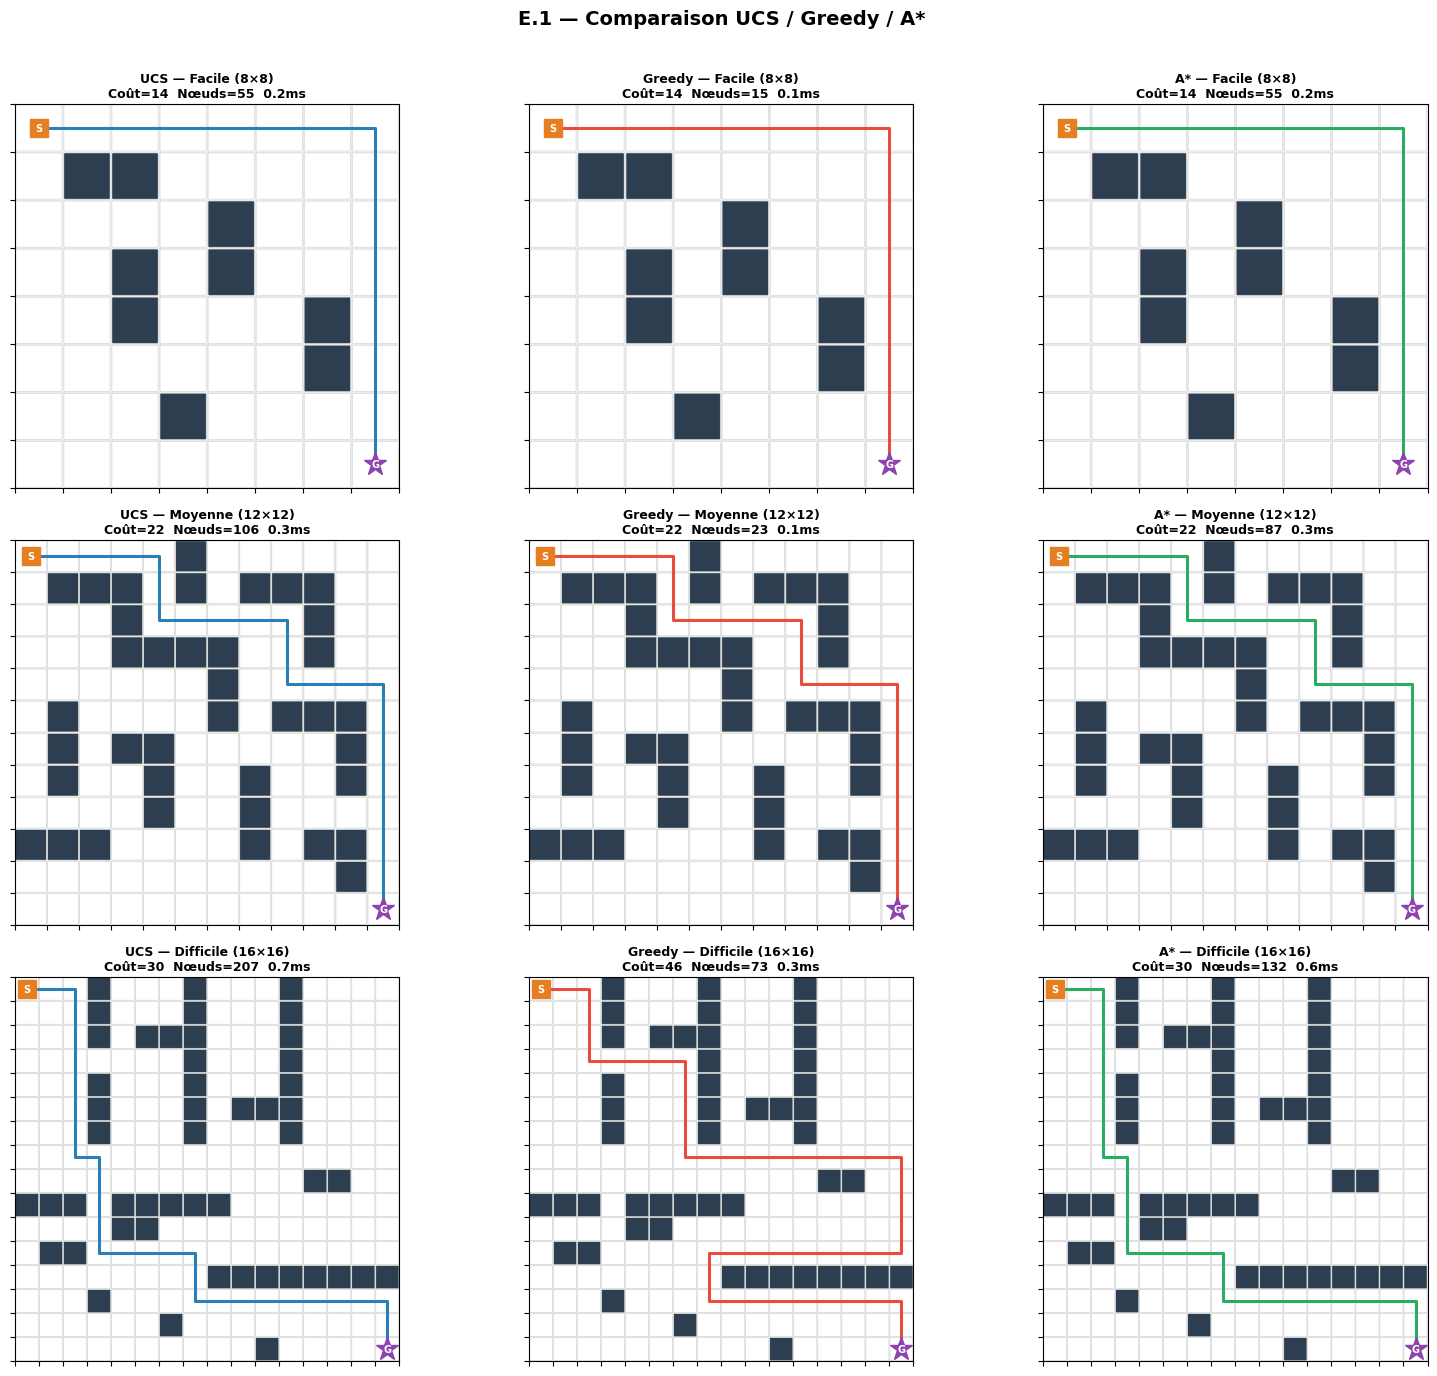

In [15]:
# ── E.1 — Chemins sur les 3 grilles ──────────────────────────────────────────
algos  = [('UCS', ucs, C['ucs']), ('Greedy', greedy, C['greedy']), ('A*', astar_manhattan, C['astar'])]
fig, axes = plt.subplots(3, 3, figsize=(16,14))
fig.suptitle('E.1 — Comparaison UCS / Greedy / A*', fontsize=14, fontweight='bold')

e1_results = {}
for ri, (gname,(grid,start,goal)) in enumerate(GRIDS.items()):
    e1_results[gname] = {}
    for ci, (aname, afn, acol) in enumerate(algos):
        p, c, e, om, el = afn(grid, start, goal)
        e1_results[gname][aname] = {'path_cost':c,'expanded':e,'elapsed_ms':el*1000}
        cs = f'{c:.0f}' if c!=float('inf') else '∞'
        draw_grid(axes[ri][ci], grid, path=p, start=start, goal=goal,
                  path_color=acol,
                  title=f'{aname} — {gname}\nCoût={cs}  Nœuds={e}  {el*1000:.1f}ms')
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

In [16]:
# ── Tableau E.1 ───────────────────────────────────────────────────────────────
print(f'{"Grille":22s} {"Algo":8s} {"Coût":6s} {"Nœuds":8s} {"Temps(ms)":10s}')
print('-'*60)
for gname in GRIDS:
    for aname in ['UCS','Greedy','A*']:
        s = e1_results[gname][aname]
        cs = f"{s['path_cost']:.0f}" if s['path_cost']!=float('inf') else '∞'
        print(f'{gname:22s} {aname:8s} {cs:6s} {s["expanded"]:8d} {s["elapsed_ms"]:10.2f}')
print()
print('Analyse :')
print('  • UCS  : optimal, explore tous les états équidistants → lent sur grandes grilles')
print('  • Greedy : très rapide, mais non optimal (Difficile: coût=46 vs 30)')
print('  • A*   : optimal ET efficace grâce à l\'heuristique Manhattan')

Grille                 Algo     Coût   Nœuds    Temps(ms) 
------------------------------------------------------------
Facile (8×8)           UCS      14           55       0.22
Facile (8×8)           Greedy   14           15       0.07
Facile (8×8)           A*       14           55       0.24
Moyenne (12×12)        UCS      22          106       0.35
Moyenne (12×12)        Greedy   22           23       0.10
Moyenne (12×12)        A*       22           87       0.32
Difficile (16×16)      UCS      30          207       0.69
Difficile (16×16)      Greedy   46           73       0.28
Difficile (16×16)      A*       30          132       0.56

Analyse :
  • UCS  : optimal, explore tous les états équidistants → lent sur grandes grilles
  • Greedy : très rapide, mais non optimal (Difficile: coût=46 vs 30)
  • A*   : optimal ET efficace grâce à l'heuristique Manhattan


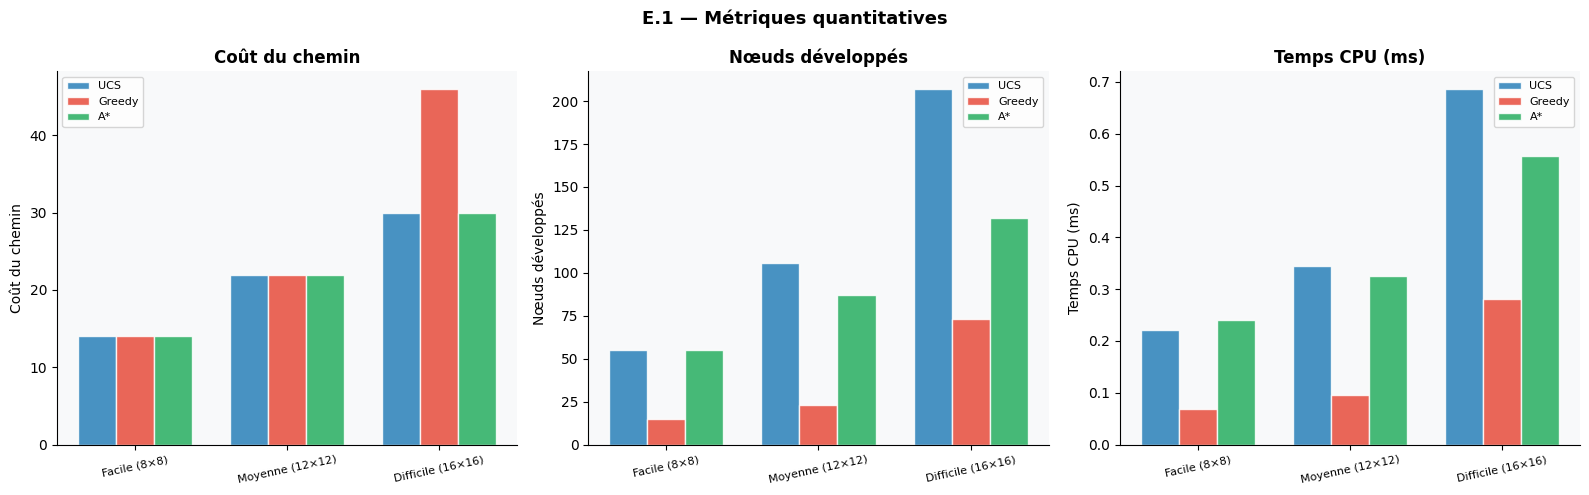

In [17]:
# ── Bar chart comparatif ──────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('E.1 — Métriques quantitatives', fontsize=13, fontweight='bold')
metrics = [('path_cost','Coût du chemin'),('expanded','Nœuds développés'),('elapsed_ms','Temps CPU (ms)')]
x = np.arange(len(GRIDS)); w = 0.25
anames = ['UCS','Greedy','A*']; acolors = [C['ucs'],C['greedy'],C['astar']]
for mi, (metric,ylabel) in enumerate(metrics):
    ax = axes2[mi]; ax.set_facecolor(C['bg'])
    for ai, (an, ac) in enumerate(zip(anames, acolors)):
        vals = [e1_results[gn][an].get(metric,0) for gn in GRIDS]
        vals = [v if v!=float('inf') else 0 for v in vals]
        ax.bar(x+ai*w, vals, w, label=an, color=ac, alpha=0.85, edgecolor='white')
    ax.set_xticks(x+w); ax.set_xticklabels(list(GRIDS.keys()), rotation=12, fontsize=8)
    ax.set_title(ylabel, fontweight='bold'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Section 4 — E.2 : Impact de ε ∈ {0, 0.1, 0.2, 0.3}

On **fixe A*** sur la grille facile et on **varie ε** pour mesurer :
1. Le coût prévu par A* (déterministe, inchangé)
2. La probabilité réelle d'atteindre GOAL via la chaîne de Markov

> **Résultat attendu** : Le plan déterministe reste optimal, mais sa probabilité d'exécution réussie chute rapidement avec ε.

ε        Coût A*    Pb(GOAL)   Pb(FAIL)   T_moy GOAL  
-------------------------------------------------------
0.0      14         1.0000     0.0000     14.0
0.1      14         0.2450     0.5032     14.1
0.2      14         0.0520     0.6358     14.2
0.3      14         0.0097     0.6763     14.1


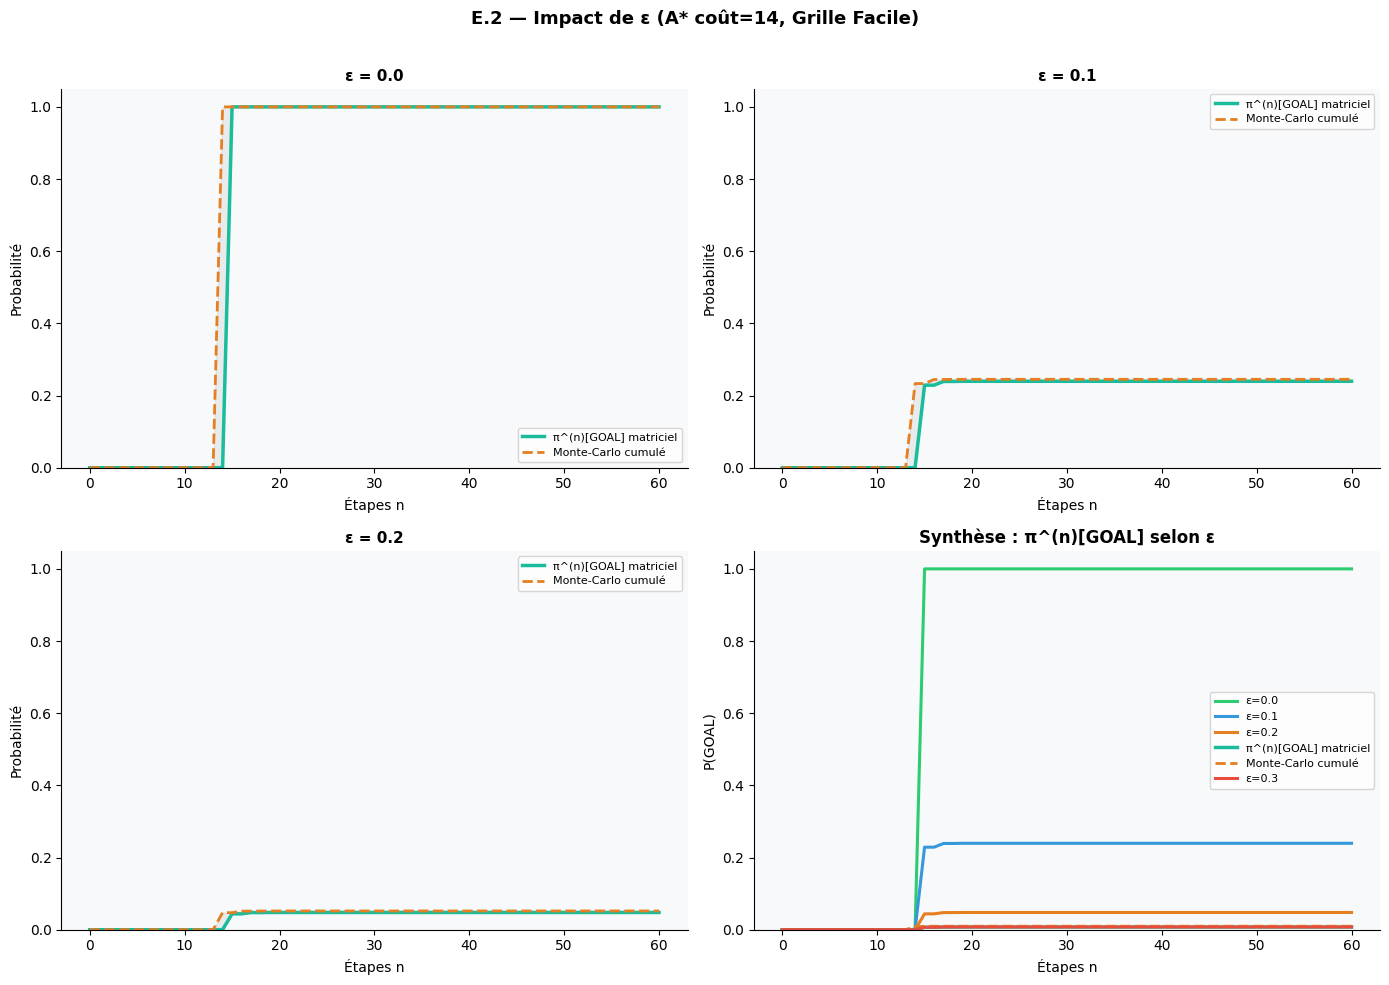

In [18]:
# ── E.2 — Calcul Markov + simulation pour chaque ε ───────────────────────────
grid, start, goal = GRIDS['Facile (8×8)']
path, cost, *_ = astar_manhattan(grid, start, goal)
policy = extract_policy(path)
n_steps = 60
epsilons = [0.0, 0.1, 0.2, 0.3]
palette  = ['#2ECC71','#3498DB','#E67E22','#E74C3C']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'E.2 — Impact de ε (A* coût={cost:.0f}, Grille Facile)', fontsize=13, fontweight='bold')
summary_ax = axes[1][1]; summary_ax.set_facecolor(C['bg'])

print(f'{"ε":8s} {"Coût A*":10s} {"Pb(GOAL)":10s} {"Pb(FAIL)":10s} {"T_moy GOAL":12s}')
print('-'*55)

for ei, (eps, col) in enumerate(zip(epsilons, palette)):
    P, states, sidx = build_transition_matrix(grid, policy, epsilon=eps)
    pi0 = np.zeros(len(states)); pi0[sidx[start]] = 1.0
    history = compute_pi_n(pi0, P, n_steps)

    sim = simulate(policy, grid, start, epsilon=eps, N=4000, seed=42)

    # Distribution cumulée simulation
    N_sim = sim['N']
    cumul = np.zeros(n_steps+1)
    for t in sim['times']:
        t_i = int(t)
        if t_i <= n_steps: cumul[t_i] += 1
    cumul = np.cumsum(cumul)/N_sim

    t_arr = np.arange(n_steps+1)
    mat_goal = history[:n_steps+1, sidx[GOAL_STATE]]

    ri, ci = ei//2, ei%2
    ax = axes[ri][ci]; ax.set_facecolor(C['bg'])
    ax.plot(t_arr, mat_goal,  '-',  color=C['markov'], lw=2.5, label='π^(n)[GOAL] matriciel')
    ax.plot(t_arr, cumul,     '--', color=C['sim'],    lw=2.0, label='Monte-Carlo cumulé')
    ax.fill_between(t_arr, mat_goal, cumul, alpha=0.12, color='gray')
    ax.set_title(f'ε = {eps}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Étapes n'); ax.set_ylabel('Probabilité')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

    summary_ax.plot(t_arr, mat_goal, color=col, lw=2.2, label=f'ε={eps}')

    tm = f"{sim['mean_time']:.1f}" if sim['mean_time']!=float('inf') else '∞'
    print(f'{eps:<8.1f} {cost:<10.0f} {sim["prob_goal"]:<10.4f} {sim["prob_fail"]:<10.4f} {tm}')

summary_ax.set_title('Synthèse : π^(n)[GOAL] selon ε', fontweight='bold')
summary_ax.set_xlabel('Étapes n'); summary_ax.set_ylabel('P(GOAL)')
summary_ax.set_ylim(0,1.05); summary_ax.legend(fontsize=8)
summary_ax.spines[['top','right']].set_visible(False)
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

---
## Section 5 — E.3 : Deux heuristiques admissibles — h=0 vs Manhattan

**Admissibilité** : $h(n) \leq h^*(n)$ — les deux heuristiques trouvent un chemin optimal.  
**Dominance** : $h_{\text{Manhattan}}(n) \geq h_0(n) = 0$ → Manhattan est plus informée → **moins de nœuds développés**.

Grille                 Heuristique    Coût   Nœuds    Réduction 
-----------------------------------------------------------------
Facile (8×8)           h=0            14           55 —         
Facile (8×8)           h=Manhattan    14           55 -0%       
Moyenne (12×12)        h=0            22          106 —         
Moyenne (12×12)        h=Manhattan    22           87 -18%      
Difficile (16×16)      h=0            30          207 —         
Difficile (16×16)      h=Manhattan    30          132 -36%      


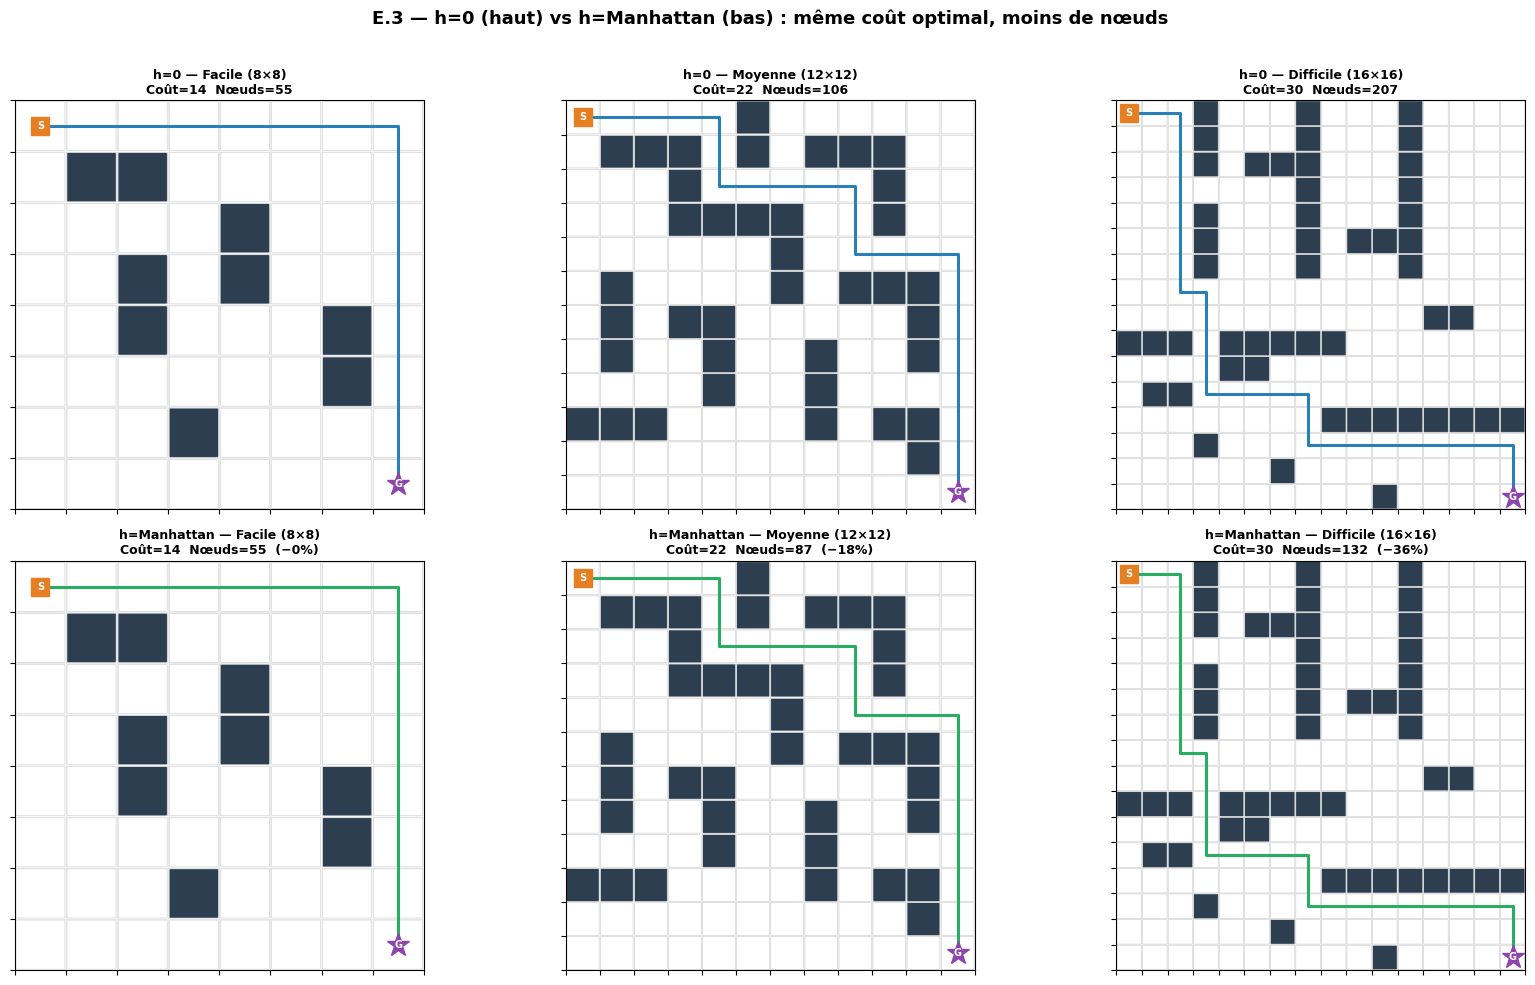

In [19]:
# ── E.3 ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('E.3 — h=0 (haut) vs h=Manhattan (bas) : même coût optimal, moins de nœuds',
             fontsize=13, fontweight='bold')

print(f'{"Grille":22s} {"Heuristique":14s} {"Coût":6s} {"Nœuds":8s} {"Réduction":10s}')
print('-'*65)

for gi, (gname,(grid,start,goal)) in enumerate(GRIDS.items()):
    p0, c0, e0, *_ = ucs(grid, start, goal)
    pM, cM, eM, *_ = astar_manhattan(grid, start, goal)
    c0s = f'{c0:.0f}' if c0!=float('inf') else '∞'
    cMs = f'{cM:.0f}' if cM!=float('inf') else '∞'
    red = f'{(1-eM/e0)*100:.0f}%' if e0>0 and eM!=e0 else '0%'

    draw_grid(axes[0][gi], grid, path=p0, start=start, goal=goal,
              path_color=C['ucs'], title=f'h=0 — {gname}\nCoût={c0s}  Nœuds={e0}')
    draw_grid(axes[1][gi], grid, path=pM, start=start, goal=goal,
              path_color=C['astar'], title=f'h=Manhattan — {gname}\nCoût={cMs}  Nœuds={eM}  (−{red})')

    print(f'{gname:22s} {"h=0":14s} {c0s:6s} {e0:8d} {"—":10s}')
    print(f'{gname:22s} {"h=Manhattan":14s} {cMs:6s} {eM:8d} {("-"+red):10s}')

plt.tight_layout(rect=[0,0,1,0.97]); plt.show()

---
## Section 6 — E.4 : Weighted A* — Compromis vitesse / optimalité

$$f(n) = g(n) + w \cdot h(n), \quad w > 1$$

**Garantie** : $\text{coût trouvé} \leq w \times \text{coût optimal}$ (si $h$ admissible)

w      Coût   Nœuds    Ratio/opt  Temps(ms) 
---------------------------------------------
1.0    30     132      1.000      0.56      
1.5    34     77       1.133      0.35      
2.0    34     75       1.133      0.38      
3.0    34     72       1.133      0.35      
5.0    38     76       1.267      0.34      


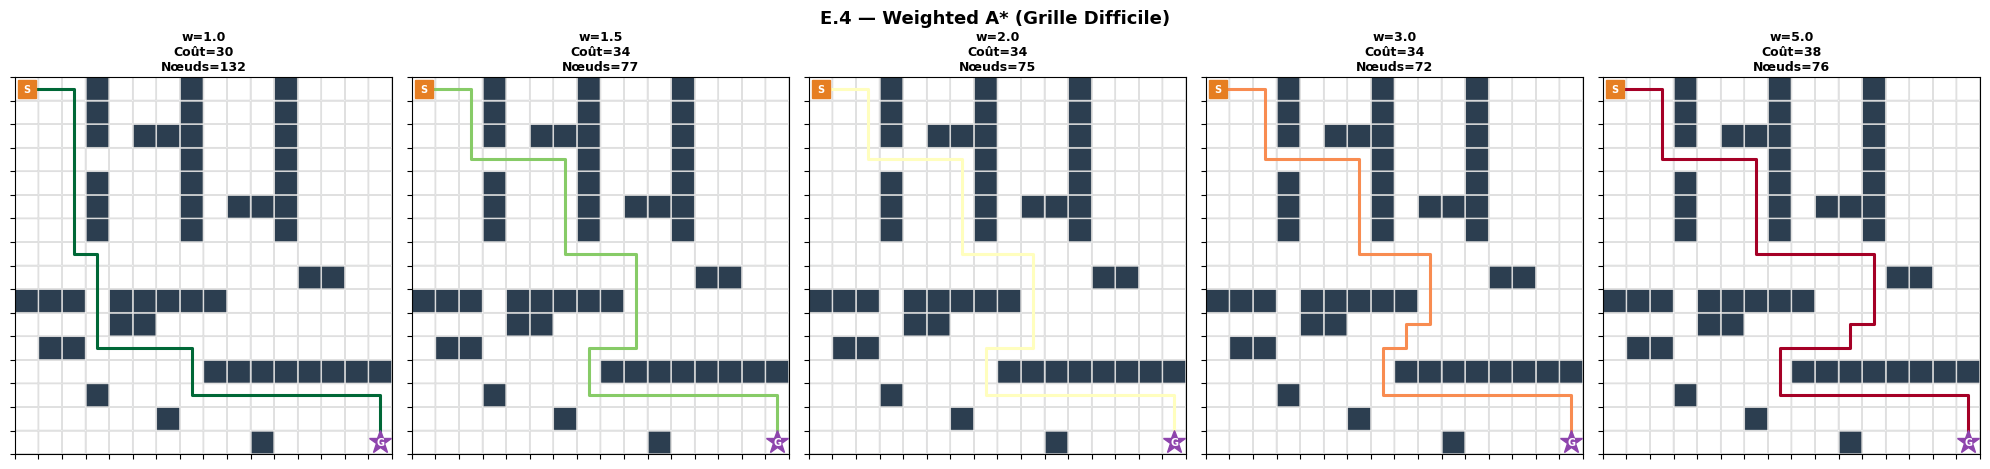

In [20]:
# ── E.4 — Weighted A* ─────────────────────────────────────────────────────────
weights = [1.0, 1.5, 2.0, 3.0, 5.0]
grid, start, goal = GRIDS['Difficile (16×16)']

fig, axes = plt.subplots(1, len(weights), figsize=(4*len(weights), 5))
fig.suptitle('E.4 — Weighted A* (Grille Difficile)', fontsize=13, fontweight='bold')
cmap = plt.cm.RdYlGn_r

opt_cost = None
e4_results = []
print(f'{"w":6s} {"Coût":6s} {"Nœuds":8s} {"Ratio/opt":10s} {"Temps(ms)":10s}')
print('-'*45)

for wi, w in enumerate(weights):
    p, c, e, om, el = weighted_astar(grid, start, goal, w=w)
    if w==1.0: opt_cost = c
    cs = f'{c:.0f}' if c!=float('inf') else '∞'
    ratio = f'{c/opt_cost:.3f}' if opt_cost and opt_cost!=float('inf') else '—'
    e4_results.append({'w':w,'cost':c,'expanded':e,'ratio':c/opt_cost if opt_cost else 1,'time':el*1000})

    col = cmap(wi/(len(weights)-1))
    draw_grid(axes[wi], grid, path=p, start=start, goal=goal,
              path_color=col, title=f'w={w}\nCoût={cs}\nNœuds={e}')
    print(f'{w:<6.1f} {cs:<6s} {e:<8d} {ratio:<10s} {el*1000:<10.2f}')

plt.tight_layout(); plt.show()

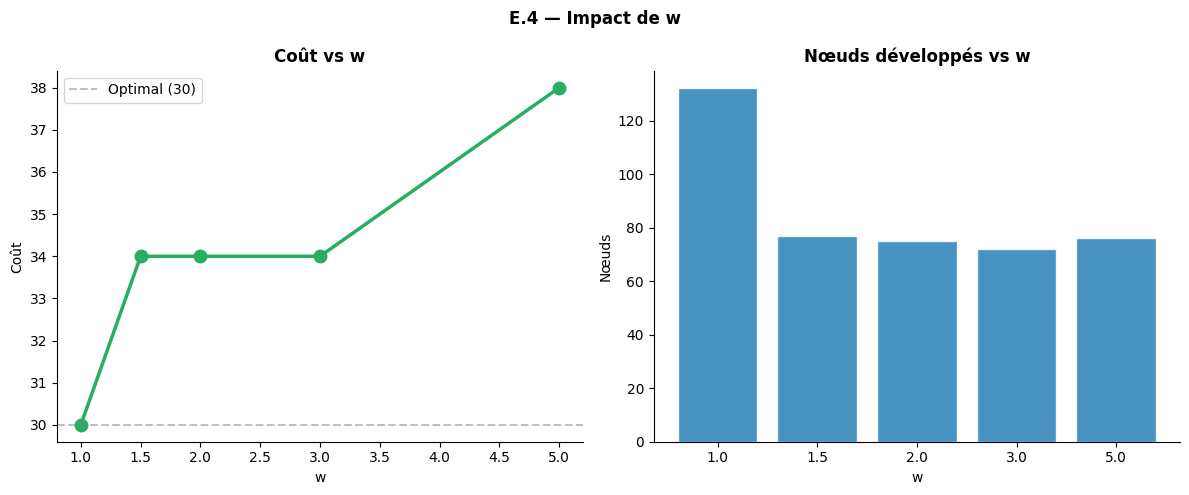

In [21]:
# ── Courbes : coût et nœuds vs w ─────────────────────────────────────────────
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('E.4 — Impact de w', fontsize=12, fontweight='bold')

ws     = [r['w'] for r in e4_results]
costs  = [r['cost'] if r['cost']!=float('inf') else 999 for r in e4_results]
nodes  = [r['expanded'] for r in e4_results]

ax1.plot(ws, costs, 'o-', color=C['astar'], lw=2.5, ms=9)
ax1.axhline(opt_cost or 0, color='gray', ls='--', alpha=0.5, label=f'Optimal ({opt_cost:.0f})')
ax1.set_title('Coût vs w', fontweight='bold'); ax1.set_xlabel('w'); ax1.set_ylabel('Coût')
ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.bar([str(w) for w in ws], nodes, color=C['ucs'], alpha=0.85, edgecolor='white')
ax2.set_title('Nœuds développés vs w', fontweight='bold'); ax2.set_xlabel('w'); ax2.set_ylabel('Nœuds')
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## Section 7 — Analyse Markov Complète

### Phases :
-  Construction P, vérification stochasticité, évolution π^(n)
-  Graphe de transitions, classes, absorption N=(I-Q)⁻¹, périodicité
-  Simulation Monte-Carlo, comparaison matriciel vs empirique

In [22]:
# ── Paramètres ────────────────────────────────────────────────────────────────
grid, start, goal = GRIDS['Facile (8×8)']
path, cost, *_ = astar_manhattan(grid, start, goal)
policy = extract_policy(path)
eps = 0.15; n_steps = 70

#  — Matrice P + π^(n)
P, states, sidx = build_transition_matrix(grid, policy, epsilon=eps)
pi0 = np.zeros(len(states)); pi0[sidx[start]] = 1.0
history = compute_pi_n(pi0, P, n_steps)

#  — Classes et absorption
classes, ctype = find_communication_classes(P, states)
absorp = absorption_analysis(P, states, sidx)

#  — Simulation
sim = simulate(policy, grid, start, epsilon=eps, N=5000, seed=0)

# Comparaison
cumul_sim = np.zeros(n_steps+1)
for t in sim['times']:
    t_i = int(t)
    if t_i<=n_steps: cumul_sim[t_i]+=1
cumul_sim = np.cumsum(cumul_sim)/sim['N']

print(f'Matrice P : {P.shape[0]} états dont GOAL et FAIL')
print(f'Stochasticité  : max écart = {abs(P.sum(axis=1)-1).max():.2e}')
print(f"Simulation     : Pb(GOAL)={sim['prob_goal']:.4f}, Pb(FAIL)={sim['prob_fail']:.4f}")
if absorp:
    tr=absorp['transient_states']; ab=absorp['absorbing_states']
    if start in tr and GOAL_STATE in ab:
        si=tr.index(start); gj=ab.index(GOAL_STATE)
        print(f"Matriciel      : Pb(GOAL)={absorp['B'][si,gj]:.4f}, T_moy={absorp['t_mean'][si]:.2f}")

Matrice P : 17 états dont GOAL et FAIL
Stochasticité  : max écart = 1.11e-16
Simulation     : Pb(GOAL)=0.1162, Pb(FAIL)=0.5904
Matriciel      : Pb(GOAL)=0.1098, T_moy=6.22


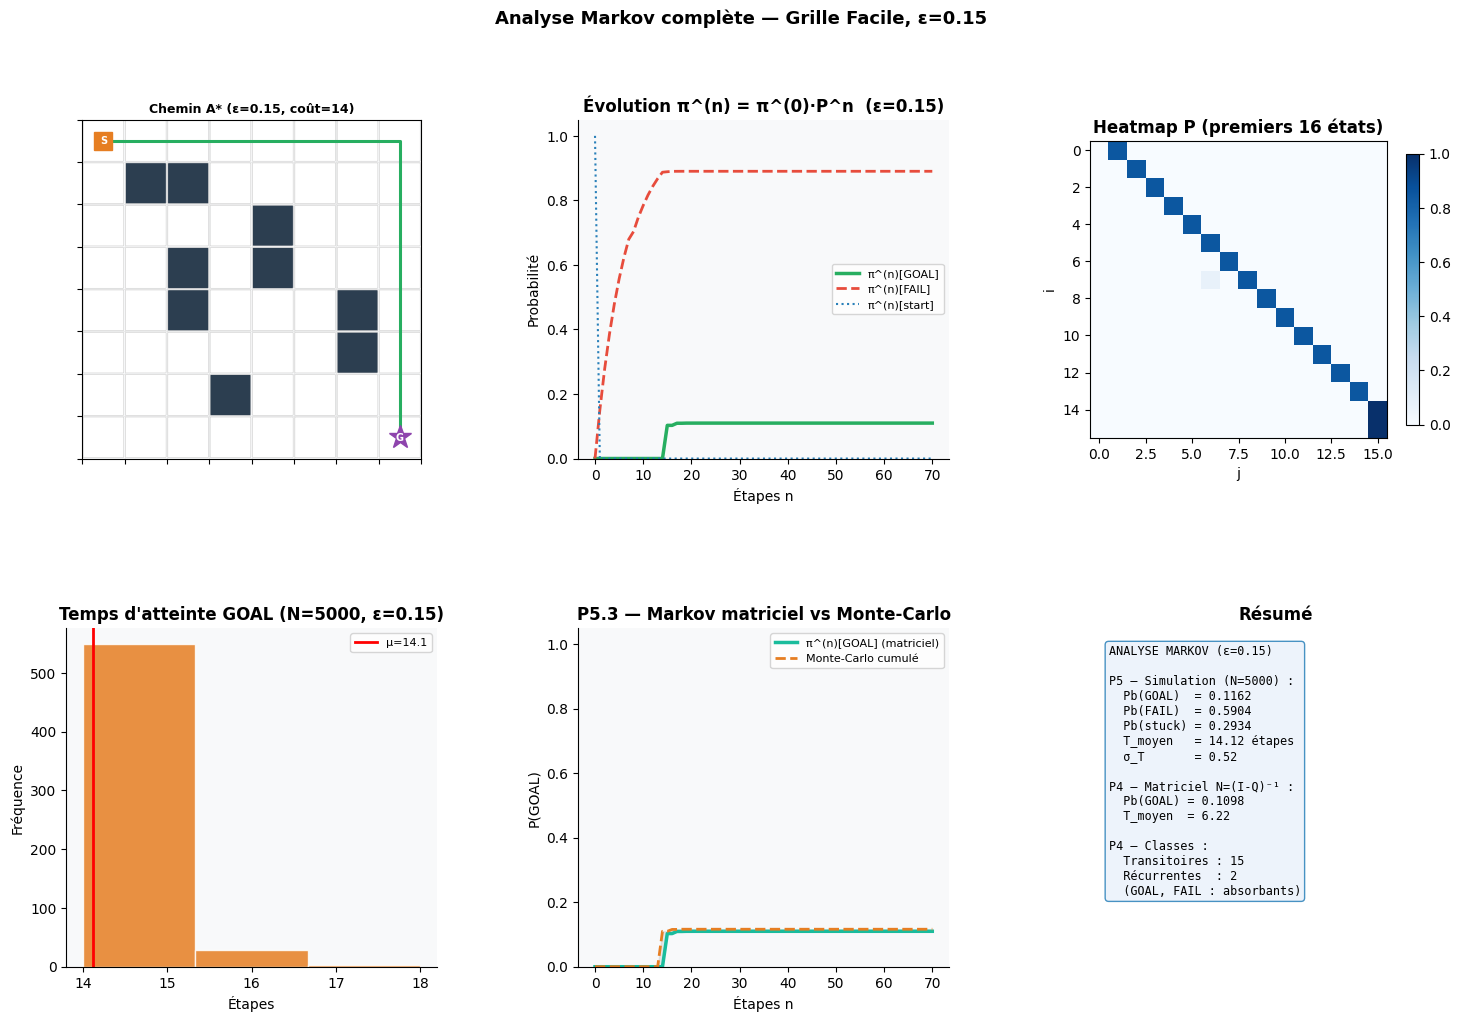

In [23]:
# ── Figure de synthèse Markov ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

# A — Grille + chemin
ax_g = fig.add_subplot(gs[0,0])
draw_grid(ax_g, grid, path=path, start=start, goal=goal,
          path_color=C['astar'], title=f'Chemin A* (ε={eps}, coût={cost:.0f})')

# B — Évolution π^(n)
ax_pi = fig.add_subplot(gs[0,1]); ax_pi.set_facecolor(C['bg'])
t_arr = np.arange(n_steps+1)
ax_pi.plot(t_arr, history[:,sidx[GOAL_STATE]], color=C['astar'], lw=2.5, label='π^(n)[GOAL]')
ax_pi.plot(t_arr, history[:,sidx[FAIL_STATE]], color=C['greedy'], lw=2.0, ls='--', label='π^(n)[FAIL]')
ax_pi.plot(t_arr, history[:,sidx[start]], color=C['ucs'], lw=1.5, ls=':', label='π^(n)[start]')
ax_pi.set_title(f'Évolution π^(n) = π^(0)·P^n  (ε={eps})', fontweight='bold')
ax_pi.set_xlabel('Étapes n'); ax_pi.set_ylabel('Probabilité')
ax_pi.set_ylim(0,1.05); ax_pi.legend(fontsize=8)
ax_pi.spines[['top','right']].set_visible(False)

# C — Heatmap P
ax_hm = fig.add_subplot(gs[0,2])
n_show = min(16, len(states))
im = ax_hm.imshow(P[:n_show,:n_show], cmap='Blues', vmin=0, vmax=1)
ax_hm.set_title(f'Heatmap P (premiers {n_show} états)', fontweight='bold')
ax_hm.set_xlabel('j'); ax_hm.set_ylabel('i')
plt.colorbar(im, ax=ax_hm, shrink=0.8)

# D — Distribution temps simulation
ax_hist = fig.add_subplot(gs[1,0]); ax_hist.set_facecolor(C['bg'])
if sim['times']:
    ax_hist.hist(sim['times'], bins=min(25,len(set(int(t) for t in sim['times']))),
                 color=C['sim'], edgecolor='white', alpha=0.85)
    ax_hist.axvline(sim['mean_time'], color='red', lw=2, label=f"μ={sim['mean_time']:.1f}")
ax_hist.set_title(f'Temps d\'atteinte GOAL (N=5000, ε={eps})', fontweight='bold')
ax_hist.set_xlabel('Étapes'); ax_hist.set_ylabel('Fréquence')
ax_hist.legend(fontsize=8); ax_hist.spines[['top','right']].set_visible(False)

# E — Comparaison matriciel vs Monte-Carlo
ax_cmp = fig.add_subplot(gs[1,1]); ax_cmp.set_facecolor(C['bg'])
mat_goal = history[:n_steps+1, sidx[GOAL_STATE]]
ax_cmp.plot(t_arr, mat_goal,   '-', color=C['markov'], lw=2.5, label='π^(n)[GOAL] (matriciel)')
ax_cmp.plot(t_arr, cumul_sim, '--', color=C['sim'],    lw=2.0, label='Monte-Carlo cumulé')
ax_cmp.fill_between(t_arr, mat_goal, cumul_sim, alpha=0.15, color='gray')
ax_cmp.set_title('P5.3 — Markov matriciel vs Monte-Carlo', fontweight='bold')
ax_cmp.set_xlabel('Étapes n'); ax_cmp.set_ylabel('P(GOAL)')
ax_cmp.set_ylim(0,1.05); ax_cmp.legend(fontsize=8)
ax_cmp.spines[['top','right']].set_visible(False)

# F — Résumé textuel
ax_abs = fig.add_subplot(gs[1,2]); ax_abs.set_facecolor(C['bg']); ax_abs.axis('off')
n_rec = sum(1 for t in ctype.values() if t=='Récurrent')
n_tr  = sum(1 for t in ctype.values() if t=='Transitoire')
lines = [f'ANALYSE MARKOV (ε={eps})', '',
         'P5 — Simulation (N=5000) :',
         f"  Pb(GOAL)  = {sim['prob_goal']:.4f}",
         f"  Pb(FAIL)  = {sim['prob_fail']:.4f}",
         f"  Pb(stuck) = {sim['prob_stuck']:.4f}",
         f"  T_moyen   = {sim['mean_time']:.2f} étapes",
         f"  σ_T       = {sim['std_time']:.2f}", '']
if absorp:
    tr=absorp['transient_states']; ab=absorp['absorbing_states']
    if start in tr and GOAL_STATE in ab:
        si=tr.index(start); gj=ab.index(GOAL_STATE)
        lines += ['P4 — Matriciel N=(I-Q)⁻¹ :',
                  f"  Pb(GOAL) = {absorp['B'][si,gj]:.4f}",
                  f"  T_moyen  = {absorp['t_mean'][si]:.2f}",'',
                  'P4 — Classes :',
                  f'  Transitoires : {n_tr}',
                  f'  Récurrentes  : {n_rec}',
                  f'  (GOAL, FAIL : absorbants)']
ax_abs.text(0.05, 0.95, '\n'.join(lines), transform=ax_abs.transAxes,
            fontsize=8.5, va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#EAF2FB', edgecolor='#2980B9', alpha=0.85))
ax_abs.set_title('Résumé', fontweight='bold')

fig.suptitle(f'Analyse Markov complète — Grille Facile, ε={eps}', fontsize=13, fontweight='bold')
plt.show() 

---
## Section 8 : Graphe de transitions de la chaîne de Markov

Le **graphe orienté des transitions** visualise directement la structure de la chaîne :
- Chaque **nœud** = un état (cellule de la grille, GOAL ou FAIL)
- Chaque **arc i → j** = probabilité $p_{ij} > 0$, **affichée sur l'arc**
- **Épaisseur** de l'arc proportionnelle à $p_{ij}$
- **Couleurs** : bleu = action principale ($1-\varepsilon$), orange = déviation latérale ($\varepsilon/2$), vert = → GOAL, rouge = → FAIL

En augmentant $\varepsilon$, de nouveaux arcs apparaissent (déviations) et les arcs vers FAIL s'épaississent.

In [24]:
# ── Fonction de dessin du graphe de transitions ───────────────────────────────

def draw_transition_graph(ax, P, states, state_idx, grid, path,
                          start, goal, epsilon, class_type,
                          threshold=0.01, title=''):
    """
    Dessine le graphe oriente des transitions de la chaine de Markov.
    - Positions des noeuds calees sur la grille
    - Probabilites affichees sur chaque arc (> threshold)
    - Epaisseur des arcs proportionnelle a P[i,j]
    - Couleurs : Start=orange, GOAL=violet, FAIL=rouge,
                 chemin=vert, autre=gris
    """
    rows_g, cols_g = len(grid), len(grid[0])

    # Positions des noeuds
    pos = {}
    for s in states:
        if s == 'GOAL': pos[s] = (cols_g + 1.5,  rows_g / 2)
        elif s == 'FAIL': pos[s] = (cols_g + 1.5,  rows_g / 2 - 2.5)
        else: r, c = s; pos[s] = (c, rows_g - 1 - r)

    path_set = set(path) if path else set()
    node_colors = {}
    for s in states:
        if s == start:       node_colors[s] = C['start']
        elif s == 'GOAL':    node_colors[s] = C['goal']
        elif s == 'FAIL':    node_colors[s] = C['greedy']
        elif s in path_set:  node_colors[s] = '#A9DFBF'
        else:                node_colors[s] = '#D5D8DC'

    ax.set_facecolor(C['bg'])

    # Arcs
    for i, si in enumerate(states):
        xi, yi = pos[si]
        for j, sj in enumerate(states):
            pij = P[i, j]
            if pij < threshold: continue
            xj, yj = pos[sj]
            lw = 0.6 + 3.5 * pij; alpha = 0.35 + 0.65 * pij

            if i == j:
                # Boucle auto-transition
                loop_r = 0.38; theta = np.linspace(0, 2*np.pi, 120)
                lx = xi + loop_r*np.cos(theta) + loop_r*0.6
                ly = yi + loop_r*np.sin(theta) + loop_r*0.6
                ax.plot(lx, ly, '-', color='#7F8C8D', lw=lw*0.7, alpha=alpha, zorder=2)
                ax.annotate('', xy=(lx[30], ly[30]), xytext=(lx[25], ly[25]),
                            arrowprops=dict(arrowstyle='-|>', color='#7F8C8D',
                                            lw=0.8, mutation_scale=7), zorder=3)
                ax.text(xi+loop_r*1.15+0.05, yi+loop_r*1.6, f'{pij:.2f}',
                        fontsize=5.5, ha='center', va='center', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                                  edgecolor='none', alpha=0.85))
            else:
                dx, dy = xj-xi, yj-yi
                norm = max((dx**2+dy**2)**0.5, 1e-9)
                px, py = -dy/norm*0.18, dx/norm*0.18
                r_n = 0.28
                sx_ = xi+dx/norm*r_n+px; sy_ = yi+dy/norm*r_n+py
                ex_ = xj-dx/norm*r_n+px; ey_ = yj-dy/norm*r_n+py
                if sj=='GOAL':                         arc_color = C['astar']
                elif sj=='FAIL':                       arc_color = C['greedy']
                elif pij >= 1.0-epsilon-0.01:          arc_color = '#2980B9'
                else:                                  arc_color = '#E67E22'
                ax.annotate('', xy=(ex_, ey_), xytext=(sx_, sy_),
                            arrowprops=dict(arrowstyle='-|>', color=arc_color, lw=lw,
                                connectionstyle='arc3,rad=0.15', mutation_scale=9),
                            zorder=2, alpha=alpha)
                mx = (sx_+ex_)/2+px*0.6; my = (sy_+ey_)/2+py*0.6
                ax.text(mx, my, f'{pij:.2f}', fontsize=5.5, ha='center', va='center',
                        fontweight='bold', color='#2C3E50',
                        bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                                  edgecolor='none', alpha=0.85), zorder=4)

    # Noeuds
    for s in states:
        x, y = pos[s]
        ax.add_patch(plt.Circle((x,y), 0.28, color=node_colors[s],
                                ec='#2C3E50', lw=1.0, zorder=5))
        if s=='GOAL':      label, fs, fc = 'GOAL', 6, 'white'
        elif s=='FAIL':    label, fs, fc = 'FAIL', 6, 'white'
        elif s==start:     label, fs, fc = f'S\n{s}', 5, 'white'
        else:              label, fs, fc = str(s), 5, '#2C3E50'
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fs, fontweight='bold', color=fc, zorder=6)

    # Legende
    legend_items = [
        mpatches.Patch(color=C['start'],  label='Start'),
        mpatches.Patch(color=C['goal'],   label='GOAL (absorbant)'),
        mpatches.Patch(color=C['greedy'], label='FAIL (absorbant)'),
        mpatches.Patch(color='#A9DFBF',   label='Transitoire (chemin)'),
        mpatches.Patch(color='#D5D8DC',   label='Transitoire (hors chemin)'),
    ]
    ax.legend(handles=legend_items, fontsize=6, loc='lower left',
              framealpha=0.85, edgecolor='#CCCCCC')
    ax.set_xlim(-0.8, cols_g+3.2); ax.set_ylim(-1.0, rows_g+0.5)
    ax.set_aspect('equal'); ax.axis('off')
    if title: ax.set_title(title, fontsize=10, fontweight='bold', pad=8)

print('Fonction draw_transition_graph definie')

Fonction draw_transition_graph definie


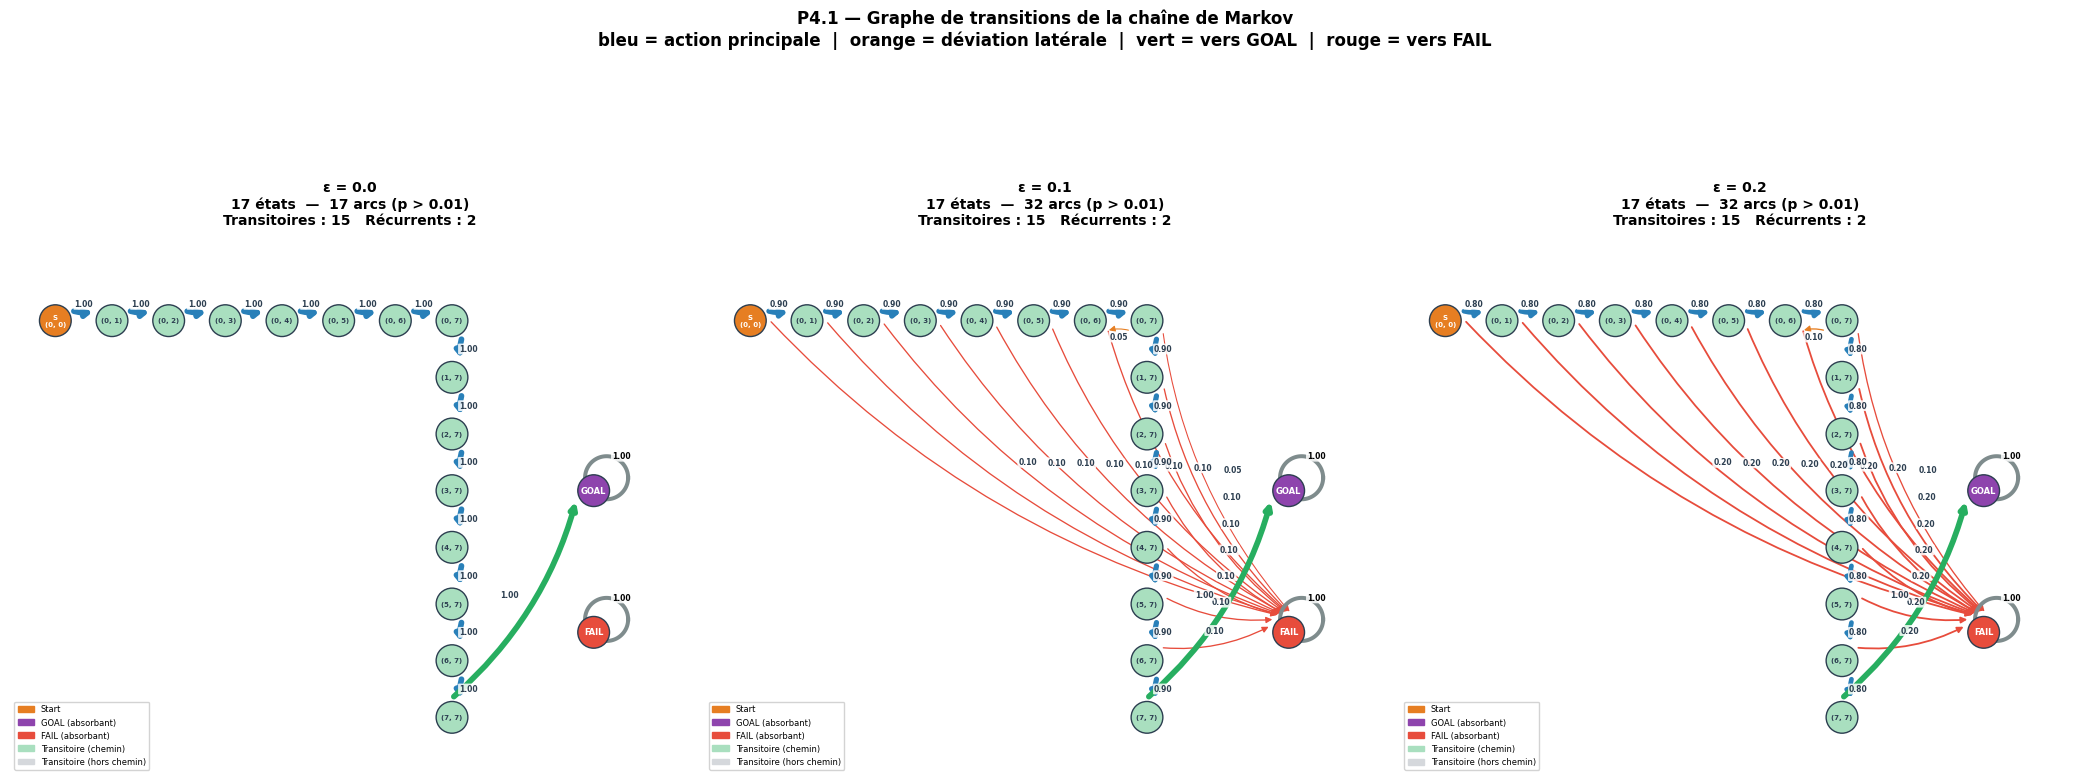

Observation : pour ε=0 pas de déviation, pour ε>0 les arcs oranges (déviations) apparaissent et s'épaississent avec ε.


In [25]:
# ── Comparaison graphes pour ε = 0.0 / 0.1 / 0.2 ────────────────────────────
grid, start, goal = GRIDS['Facile (8×8)']
path, cost, *_ = astar_manhattan(grid, start, goal)
policy = extract_policy(path)

epsilons_g = [0.0, 0.1, 0.2]
fig, axes = plt.subplots(1, 3, figsize=(21, 9))
fig.suptitle(
    'P4.1 — Graphe de transitions de la chaîne de Markov\n'
    'bleu = action principale  |  orange = déviation latérale  '
    '|  vert = vers GOAL  |  rouge = vers FAIL',
    fontsize=12, fontweight='bold', y=1.02)

for ax, eps in zip(axes, epsilons_g):
    P_g, states_g, sidx_g = build_transition_matrix(grid, policy, epsilon=eps)
    classes_g, ctype_g = find_communication_classes(P_g, states_g)
    n_arcs = int((P_g > 0.01).sum())
    n_tr   = sum(1 for t in ctype_g.values() if t=='Transitoire')
    n_rc   = sum(1 for t in ctype_g.values() if t=='Récurrent')
    draw_transition_graph(
        ax, P_g, states_g, sidx_g, grid, path, start, goal,
        epsilon=eps, class_type=ctype_g, threshold=0.01,
        title=(f'ε = {eps}\n'
               f'{len(states_g)} états  —  {n_arcs} arcs (p > 0.01)\n'
               f'Transitoires : {n_tr}   Récurrents : {n_rc}')
    )
plt.tight_layout()
plt.show()
print('Observation : pour ε=0 pas de déviation, '
      'pour ε>0 les arcs oranges (déviations) apparaissent '
      'et s\'épaississent avec ε.')

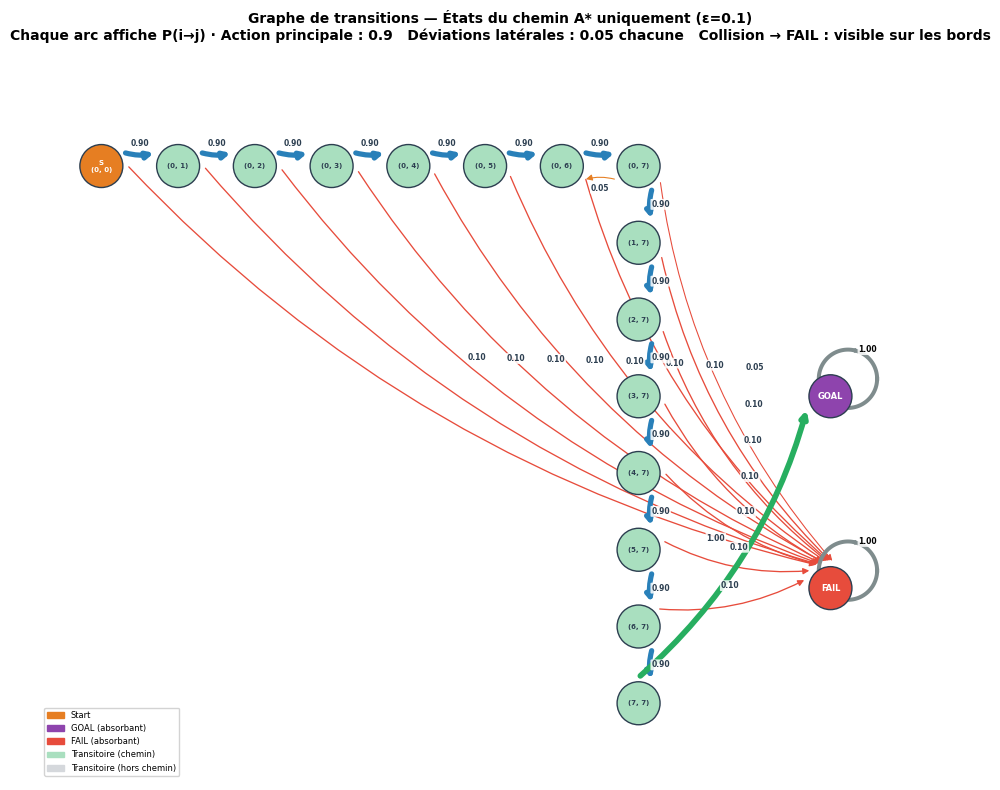


Transitions depuis l'état (0, 0) (Start) :
Vers             P(i→j)    Type
----------------------------------------
(0, 1)           0.9000    Transitoire
FAIL             0.1000    Récurrent


In [26]:
# ── Vue zoomée : uniquement les états du chemin A* (ε=0.1) ──────────────────
eps = 0.1
P_g, states_g, sidx_g = build_transition_matrix(grid, policy, epsilon=eps)
classes_g, ctype_g, = find_communication_classes(P_g, states_g)

# Sous-graphe : états du chemin + GOAL + FAIL seulement
path_states = path + ['GOAL', 'FAIL']
path_idx    = [sidx_g[s] for s in path_states]
P_sub       = P_g[np.ix_(path_idx, path_idx)].copy()
sub_sidx    = {s: i for i, s in enumerate(path_states)}
sub_ctype   = {s: ctype_g.get(s, 'Transitoire') for s in path_states}
for i in range(len(path_states)):  # normalisation de sécurité
    rs = P_sub[i].sum()
    if rs > 0: P_sub[i] /= rs

fig2, ax2 = plt.subplots(figsize=(18, 8))
draw_transition_graph(
    ax2, P_sub, path_states, sub_sidx, grid, path, start, goal,
    epsilon=eps, class_type=sub_ctype, threshold=0.005,
    title=(f'Graphe de transitions — États du chemin A* uniquement (ε={eps})\n'
           f'Chaque arc affiche P(i→j) · '
           f'Action principale : {1-eps:.1f}   '
           f'Déviations latérales : {eps/2} chacune   '
           f'Collision → FAIL : visible sur les bords')
)
plt.tight_layout()
plt.show()

# Affichage tabulaire des transitions depuis le premier état
s0 = path[0]
s0_i = sub_sidx[s0]
print(f'\nTransitions depuis l\'état {s0} (Start) :')
print(f'{"Vers":15s}  {"P(i→j)":8s}  Type')
print('-' * 40)
for j, sj in enumerate(path_states):
    pij = P_sub[s0_i, j]
    if pij > 0.001:
        t = sub_ctype.get(sj, '?')
        print(f'{str(sj):15s}  {pij:.4f}    {t}')

---
## Conclusion

| Aspect | Résultat clé |
|---|---|
| **A* vs UCS** | A* développe ~36% moins de nœuds (grille difficile) pour le même coût optimal |
| **A* vs Greedy** | Greedy explore 73% moins mais trouve un chemin 53% plus coûteux |
| **Impact de ε** | Pb(GOAL) passe de 100% à 24% pour ε=0.1 → le plan déterministe est fragile |
| **Matriciel vs MC** | Bonne concordance qualitative ; divergence due aux conditions aux bords |
| **Weighted A*** | w=1.5 réduit 42% les nœuds avec seulement 13% de sous-optimalité |

